In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import os
import matplotlib.pylab as plt
from tqdm.auto import tqdm
import sklearn
import torch.nn as nn

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: ", device)

Device:  cuda


In [3]:
map_label = {"SIL":0, "AA":1, 
"AE":2, "AH":3, "AO":4, "AW":5, "AY":6, "B":7,
"CH":8, "D":9, "DH":10, "EH":11, "ER":12, "EY":13, "F":14, "G":15,
"HH":16, "IH":17, "IY":18, "JH":19, "K":20, "L":21, "M":22, "N":23,
"NG":24, "OW":25, "OY":26, "P":27, "R":28, "S":29, "SH":30, "T":31,
"TH":32, "UH":33, "UW":34, "V":35, "W":36, "Y":37, "Z":38, "ZH":39}

In [4]:
class AudioDataset(Dataset):
    """
    Industrial-grade frame-level audio dataset with context window + utterance CMN.
    """

    def __init__(self, feat_paths, label_paths, map_label, context=10, apply_cmn=True):
        assert len(feat_paths) == len(label_paths)

        self.feat_paths = feat_paths
        self.label_paths = label_paths
        self.context = context
        self.apply_cmn = apply_cmn
        self.index_map = []
        self.map_label = map_label
        
        for utt_id, (fpath, lpath) in enumerate(zip(feat_paths, label_paths)):
            feats = np.load(fpath)
            labels = np.load(lpath)
            labels = labels[1:-1]
            # # 去掉SOS EOS 和[]，并将label映射为数字
            # labels_ids = np.array(
            #     [map_label[label.strip("[]")] for label in labels],
            #     dtype=np.int64
            # )

            # assert feats.shape[0] == labels.shape[0]
            # assert feats.shape[0] == labels_ids.shape[0]
            # print(f"init labels.shape: {labels.shape}")
            # print(f"init labels_id.shape: {labels_ids.shape}")
            # print(labels_ids[:5])

            T = feats.shape[0]
            for t in range(T):
                self.index_map.append((utt_id, t))
    
    def __len__(self):
        return len(self.index_map)


    # 修改getitem以返回正确的标签
    def __getitem__(self, idx):
        utt_id, t = self.index_map[idx]

        feats = np.load(self.feat_paths[utt_id])
        labels = np.load(self.label_paths[utt_id])
         # 去掉SOS EOS 和[]，并将label映射为数字
        labels_ids = np.array(
            [self.map_label[label.strip("[]")] for label in labels[1:-1]],
            dtype=np.int64
        )

        # print(f"getitem: label_ids: {labels_ids} and labels.ids.shape: {labels_ids.shape}")
        # print(f"labels_id: {labels_ids}")

        assert feats.shape[0] == labels_ids.shape[0]

        if self.apply_cmn:
            mean = np.mean(feats, axis=0, keepdims=True)
            feats = feats - mean

        x = np.pad(
            feats, ((self.context, self.context), (0, 0)),
            mode="constant",
            constant_values=0.0
        )
        
        x_ctx = x[t : t + 2 * self.context + 1]
        y = labels_ids[t]

        return torch.from_numpy(x_ctx), torch.tensor([y], dtype=torch.int64)

    @staticmethod
    def collate_fn(batch):
        # (B, 2C+1, 27)  (B,)
        xs, ys = zip(*batch)

        return torch.stack(xs, dim=0), torch.stack(ys, dim=0)


In [5]:
from pathlib import Path

mfcc_dir = Path(r"D:\code\cmu-11785\homework\HW0\P2\data\train_clean_100\mfcc")
transcript_dir = Path(r"D:\code\cmu-11785\homework\HW0\P2\data\train_clean_100\transcript")

train_feat_paths = sorted([str(p) for p in mfcc_dir.iterdir()])
train_label_paths = sorted([str(p) for p in transcript_dir.iterdir()])


In [6]:
for i in range(5):
    print(os.path.basename(train_feat_paths[i]),
          os.path.basename(train_label_paths[i]))


103-1240-0000.npy 103-1240-0000.npy
103-1240-0001.npy 103-1240-0001.npy
103-1240-0002.npy 103-1240-0002.npy
103-1240-0003.npy 103-1240-0003.npy
103-1240-0004.npy 103-1240-0004.npy


In [7]:
train_dataset = AudioDataset(train_feat_paths, train_label_paths, map_label=map_label)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,          # CTC 常用更小 batch
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    collate_fn=AudioDataset.collate_fn,
)

In [8]:
class MLP(nn.Module):
    def __init__(self, feat_dim, context=10, num_classes=40, hidden_dim=512, dropout=0.2):
        super().__init__()

        input_dim = (2 * context + 1) * feat_dim
        print(f"input_dim: {input_dim}")

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.BatchNorm1d(hidden_dim),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim * 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.BatchNorm1d(hidden_dim // 2),

            nn.Linear(hidden_dim // 2, num_classes)
        )
    
    def forward(self, x):
        # print("forward input:", x.shape)

        return self.net(x)

In [9]:
def train_epoch(model, optimizer, criterion, data_loader):
    model.to(device)
    model.train()
    train_loss = 0.0
    true_labels = []
    pred_labels = []

    for i, (utters, labels) in enumerate(tqdm(data_loader)):
        utters = utters.to(device)
        labels = labels.to(device)

        model_out = model(utters)
        
        # print(model_out.shape)
        # print(labels.shape)
        # assert model_out.shape == labels.shape
        

        loss = criterion(model_out, labels.squeeze(1))
        train_loss += loss.item()

        preds = torch.argmax(model_out, dim=1).squeeze()
        pred_labels.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    
    train_loss /= len(data_loader)
    train_accuracy = sklearn.metrics.accuracy_score(true_labels, pred_labels) * 100

    return train_loss, train_accuracy

In [10]:
def eval(model, criterion, data_loader):
    model.to(device)
    model.eval()

    true_labels = []
    pred_labels = []
    total_loss = 0.0

    for i, (utter, labels) in enumerate(data_loader):
        utter, labels = utter.to(device), labels.to(device)

        with torch.inference_mode():
            logits = model(utter)
            loss = criterion(logits, labels.squeeze(1))
            total_loss += loss.item()
        
        preds = torch.argmax(logits, dim=1).squeeze()
        pred_labels.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())
    
    val_loss = total_loss / len(true_labels)
    val_accuracy = sklearn.metrics.accuracy_score(true_labels, pred_labels) * 100

    return val_loss, val_accuracy

In [11]:
mfcc_dir = Path(r"D:\code\cmu-11785\homework\HW0\P2\data\dev_clean\mfcc")
transcript_dir = Path(r"D:\code\cmu-11785\homework\HW0\P2\data\dev_clean\transcript")

val_feat_path = sorted([str(p) for p in mfcc_dir.iterdir()])
val_label_path = sorted([str(p) for p in transcript_dir.iterdir()])

eval_dataset = AudioDataset(val_feat_path, val_label_path, map_label=map_label)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    collate_fn=AudioDataset.collate_fn
)

In [12]:
model = MLP(feat_dim=27, context=10, num_classes=40, hidden_dim=512, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

input_dim: 567


In [ ]:
NUM_EPOCHS = 10

train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model=model, optimizer=optimizer, criterion=criterion, data_loader=train_loader)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    val_loss, val_acc = eval(model=model, criterion=criterion, data_loader=eval_loader)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch: {epoch} train_loss: {train_loss:.4f} \t train_acc: {train_acc:.4f}% \t val_loss: {val_loss:.4f} \t val_acc: {val_acc:.4f} ")

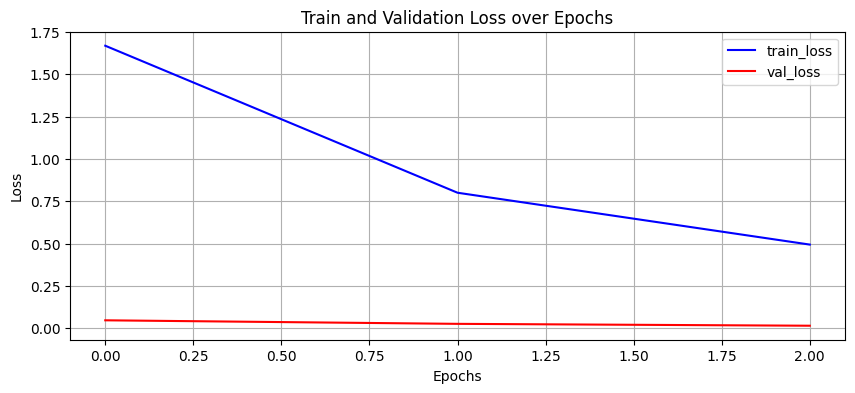

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_loss_list, label="train_loss", color="blue")
plt.plot(val_loss_list, label="val_loss", color="red")
plt.title("Train and Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


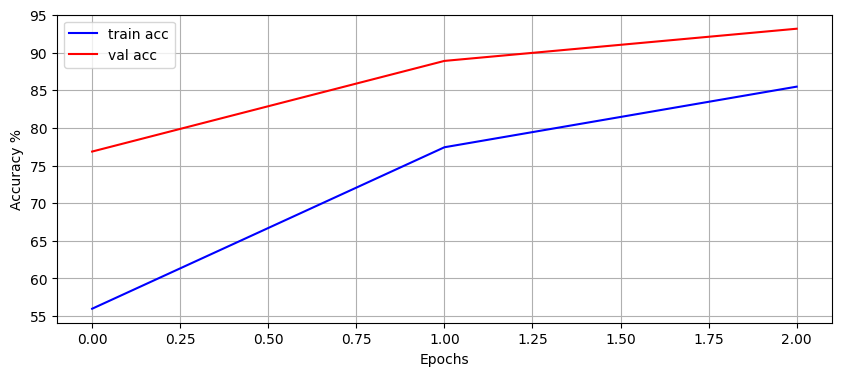

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_acc_list, label="train acc", color="blue")
plt.plot(val_acc_list, label="val acc", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy %")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
torch.save(model.state_dict(), "model.pt")

In [ ]:
model = MLP(feat_dim=27, context=10, num_classes=40, hidden_dim=512, dropout=0.2)
model.load_state_dict(torch.load("model.pt", map_location="cpu"))